In [8]:
import json

import colorcet
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis, plot_rect

In [9]:
config_id = 1

with open(f"config-{config_id}.json") as file:
    config = json.load(file)

In [12]:
chain, = config["chains"]

chain_length = chain["length"]

enhancer_intervals = []
for feature in chain["association_features"]:
    match feature:
        case {"site": {"start": start, "end": end}}:
            enhancer_intervals.append((start, end))

gene_intervals = []
gene_directions = []
for track in chain["loop_capture_tracks"]:
    match track:
        case {"start": tss, "end": tes}:
            if tss < tes:
                gene_intervals.append((tss, tes))
                gene_directions.append(+1)
            else:
                gene_intervals.append((tes, tss))
                gene_directions.append(-1)

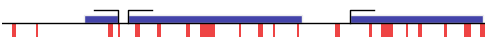

In [13]:
fig, ax = plt.subplots(figsize=(2.5, 0.3))

for (start, end), strand in zip(gene_intervals, gene_directions):
    plot_rect(ax, start, 0.5, end, 0.8, facecolor="#44a", edgecolor="#eee", zorder=1)

    if strand == +1:
        tss = start
    else:
        tss = end
    x = [tss, tss, tss + 10 * strand]
    y = [0.5, 1, 1]
    ax.plot(x, y, color="k", zorder=2)

for start, end in enhancer_intervals:
    plot_rect(ax, start, 0, end, 0.5, facecolor="#e44", edgecolor="none", zorder=1)

ax.plot([0, chain_length], [0.5, 0.5], color="k", zorder=2)

ax.set_xlim(0, chain_length)
ax.set_ylim(-0.3, 1.3)

set_axis(ax, "none")

pass